# Visibility Graph on a Globe

Spherical visibility graph construction for great-circle air routing around restricted regions.

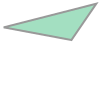

In [7]:
from shapely.geometry import Polygon

# Vertices as (lon, lat), matching GeoJSON axis order
CITIES = {
    "Bishkek": (74.59, 42.87),
    "Novosibirsk": (82.92, 55.03),
    "Atyrau": (51.92, 47.11),
}

obstacle = Polygon(CITIES.values())
obstacle

In [5]:
import pandas as pd

airports = pd.read_csv("data/airports.csv").set_index("ICAO")
route = airports.loc[["UAAA", "KJFK"], ["AirportName", "GeoPointLat", "GeoPointLong"]]
route

,AirportName,GeoPointLat,GeoPointLong
ICAO,,,
UAAA,Almaty,43.352072,77.040508
KJFK,John F Kennedy Intl,40.639751,-73.778925


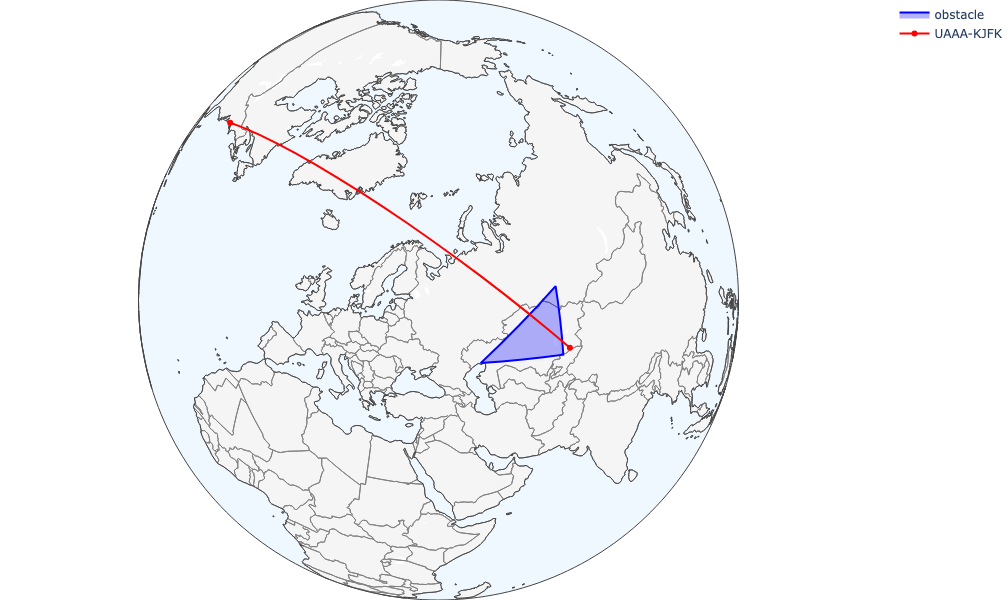

In [8]:
import plotly.graph_objects as go

# Clockwise winding: on a sphere d3 fills the region to the ring's left,
# so a counterclockwise ring paints everything except the triangle
ring = list(CITIES.values())[::-1]
lons, lats = zip(*ring)
lons = [*lons, lons[0]]  # close the ring
lats = [*lats, lats[0]]

fig = go.Figure(
    go.Scattergeo(
        lon=lons,
        lat=lats,
        mode="lines",
        line=dict(color="blue", width=2),
        fill="toself",
        fillcolor="rgba(0, 0, 255, 0.3)",
        name="obstacle",
    )
)
fig.add_trace(
    go.Scattergeo(
        lon=route["GeoPointLong"],
        lat=route["GeoPointLat"],
        mode="lines+markers",
        line=dict(color="red", width=2),
        marker=dict(color="red", size=6),
        name="UAAA-KJFK",
    )
)
fig.update_geos(
    projection_type="orthographic",
    projection_rotation=dict(lon=40, lat=60),
    showcountries=True,
    countrycolor="gray",
    showland=True,
    landcolor="whitesmoke",
    showocean=True,
    oceancolor="aliceblue",
)
fig.update_layout(height=600, margin=dict(l=0, r=0, t=0, b=0))
fig.show()